# Exercise 4: Autoregressive Image Modeling
## Submission date: 25\05\2026, 23:59.

Submitted by:

## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [25]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from IPython.display import set_matplotlib_formats
%config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [26]:
# Convert images from 0-1 to 0-255 (integers).
def discretize(sample):
    return (sample * 255).to(torch.long)

# Transformations applied on each image => only make them a tensor
transform = transforms.Compose([transforms.ToTensor(), discretize])

# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

#pl.seed_everything(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


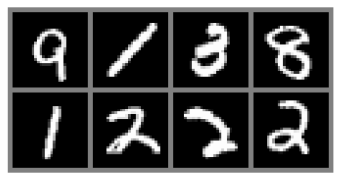

In [27]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=255)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

## Define Masked Convolutions

In [28]:
class MaskedConvolution(nn.Module):

    def __init__(self, c_in, c_out, mask, **kwargs):
        """
        Implements a convolution with mask applied on its weights.
        Inputs:
            c_in - Number of input channels
            c_out - Number of output channels
            mask - Tensor of shape [kernel_size_H, kernel_size_W] with 0s where
                   the convolution should be masked, and 1s otherwise.
            kwargs - Additional arguments for the convolution
        """
        super().__init__()
        # For simplicity: calculate padding automatically
        kernel_size = (mask.shape[0], mask.shape[1])

        # Actual convolution
        self.conv = nn.Conv2d(c_in, c_out, kernel_size, padding='same', **kwargs)

        # Mask as buffer => it is no parameter but still a tensor of the module
        # (must be moved with the devices)
        self.register_buffer('mask', mask[None,None].to(device))

    def forward(self, x):
        self.conv.weight.data *= self.mask # Ensures zero's at masked positions
        return self.conv(x)

In [29]:
class VerticalStackConvolution(MaskedConvolution):

    def __init__(self, c_in, c_out, kernel_size=3, mask_center=False, **kwargs):
        # Mask out all pixels below. For efficiency, we could also reduce the kernel
        # size in height, but for simplicity, we stick with masking here.
        mask = torch.ones(kernel_size, kernel_size)
        mask[kernel_size//2+1:,:] = 0

        # For the very first convolution, we will also mask the center row
        if mask_center:
            mask[kernel_size//2,:] = 0

        super().__init__(c_in, c_out, mask, **kwargs)

class HorizontalStackConvolution(MaskedConvolution):

    def __init__(self, c_in, c_out, kernel_size=3, mask_center=False, **kwargs):
        # Mask out all pixels on the left. Note that our kernel has a size of 1
        # in height because we only look at the pixel in the same row.
        mask = torch.ones(1,kernel_size)
        mask[0,kernel_size//2+1:] = 0

        # For the very first convolution, we will also mask the center pixel
        if mask_center:
            mask[0,kernel_size//2] = 0

        super().__init__(c_in, c_out, mask, **kwargs)

## PixelCNN without Gating and dilations

Instead of the GatedMaskConv from the tutorial, we defined a MaskedConvLayer for the model.

In [30]:
class MaskedConvLayer(nn.Module):
        def __init__(self, c_in, kernel_size=3, **kwargs):
            """
            Non Gated Convolution block implemented
            """
            super().__init__()
            self.kernel_size = kernel_size
            self.v_stack = VerticalStackConvolution(
                 c_in = c_in,
                 c_out = c_in,
                 kernel_size = self.kernel_size,
                 **kwargs
            )
            self.h_stack = HorizontalStackConvolution(
                 c_in = c_in,
                 c_out = c_in,
                 kernel_size = self.kernel_size,
                 **kwargs
            )

        def forward(self, v_stack, h_stack):
          v_stack = self.v_stack(v_stack)
          h_stack = self.h_stack(h_stack)
          h_stack = h_stack + v_stack

          h_stack = F.relu(h_stack)
          v_stack = F.relu(v_stack)
          
          return v_stack, h_stack

In [31]:
class PixelCNN(nn.Module):

    def __init__(self, c_in, c_hidden, kernel_size=3, num_layers=5):
        super().__init__()

        self.kernel_size = kernel_size
        self.conv_vstack = VerticalStackConvolution(
                 c_in = c_in,
                 c_out = c_hidden,
                 kernel_size = self.kernel_size,
                 mask_center = True
            )
        self.conv_hstack = HorizontalStackConvolution(
                 c_in = c_in,
                 c_out = c_hidden,
                 kernel_size = self.kernel_size,
                 mask_center = True
            )
        
        self.conv_layers = nn.ModuleList([MaskedConvLayer(c_in = c_hidden, kernel_size=self.kernel_size) for _ in range(num_layers)])
        self.conv_out = nn.Conv2d(c_hidden, c_in * 256, kernel_size=1)
        

    def forward(self, x):
        """
        Forward image through model and return logits for each pixel.
        Inputs:
            x - Image tensor with integer values between 0 and 255.
        """
        # Scale input from 0 to 255 back to -1 to 1
        x = (x.float() / 255.0) * 2 - 1

        # Initial convolutions
        v_stack = self.conv_vstack(x)
        h_stack = self.conv_hstack(x)

        # Other Convolutions
        for layer in self.conv_layers:
            v_stack, h_stack = layer(v_stack, h_stack)

        # Apply ELU before 1x1 convolution for non-linearity on residual connection
        out = self.conv_out(F.elu(h_stack))

        # Output dimensions: [Batch, Classes, Channels, Height, Width]
        out = out.reshape(out.shape[0], 256, out.shape[1]//256, out.shape[2], out.shape[3])

        return out

    def calc_nll(self, x):
        # Forward pass with bpd (bits per dimension) negative log likelihood calculation
        out = self(x)
        loss = F.cross_entropy(out, x) / math.log(2)
        return loss

    @torch.no_grad()
    def sample(self, img_shape, img=None):
        """
        Sampling function for the autoregressive model.
        Inputs:
            img_shape - Shape of the image to generate (B,C,H,W)
            img (optional) - If given, this tensor will be used as
                             a starting image. The pixels to fill
                             should be -1 in the input tensor.
        """
        # Create empty image
        if img is None:
            img = torch.zeros(img_shape, dtype=torch.long).to(device) - 1
        # Generation loop
        for h in tqdm(range(img_shape[2]), leave=False):
            for w in range(img_shape[3]):
                for c in range(img_shape[1]):
                    # Skip if not to be filled (-1)
                    if (img[:,c,h,w] != -1).all().item():
                        continue
                    # For efficiency, we only have to input the upper part of the image
                    # as all other parts will be skipped by the masked convolutions anyways
                    pred = self.forward(img[:,:,:h+1,:])
                    probs = F.softmax(pred[:,:,c,h,w], dim=-1)
                    img[:,c,h,w] = torch.multinomial(probs, num_samples=1).squeeze(dim=-1)
        return img

Before you start training, you have to choose hyper-parameters for your model (e.g. number of layers).

We can check the full receptive field of the model on an MNIST image of size $28\times 28$ to help you decide which hyper-parameters to use:

In [32]:
def show_center_recep_field(img, out):
    """
    Calculates the gradients of the input with respect to the output center pixel,
    and visualizes the overall receptive field.
    Inputs:
        img - Input image for which we want to calculate the receptive field on.
        out - Output features/loss which is used for backpropagation, and should be
              the output of the network/computation graph.
    """
    # Determine gradients
    loss = out[0,:,img.shape[2]//2,img.shape[3]//2].sum() # L1 loss for simplicity
    loss.backward(retain_graph=True) # Retain graph as we want to stack multiple layers and show the receptive field of all of them
    img_grads = img.grad.abs()
    img.grad.fill_(0) # Reset grads

    # Plot receptive field
    img = img_grads.squeeze().cpu().numpy()
    fig, ax = plt.subplots(1,2)
    pos = ax[0].imshow(img)
    ax[1].imshow(img>0)
    # Mark the center pixel in red if it doesn't have any gradients (should be the case for standard autoregressive models)
    show_center = (img[img.shape[0]//2,img.shape[1]//2] == 0)
    if show_center:
        center_pixel = np.zeros(img.shape + (4,))
        center_pixel[center_pixel.shape[0]//2,center_pixel.shape[1]//2,:] = np.array([1.0, 0.0, 0.0, 1.0])
    for i in range(2):
        ax[i].axis('off')
        if show_center:
            ax[i].imshow(center_pixel)
    ax[0].set_title("Weighted receptive field")
    ax[1].set_title("Binary receptive field")
    plt.show()
    plt.close()

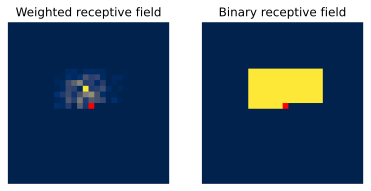

In [33]:
test_model = PixelCNN(c_in=1, c_hidden=64).to('cpu')      # adjust according to your model
inp = torch.zeros(1,1,28,28).to('cpu')                    # do not remove the 'cpu' here
inp.requires_grad_()
out = test_model(inp)
show_center_recep_field(inp, out.squeeze(dim=2))
del inp, out, test_model

## Model Training

In [34]:
model = PixelCNN(c_in=1, c_hidden=128, kernel_size=5)       # adjust according to your model
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

model = torch.compile(model.to(device))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
epochs = 100

Num params: 2,496,000


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/100, Train Loss: 1.3574, Val Loss: 1.1706


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 4/100, Train Loss: 1.1172, Val Loss: 1.1193


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 5/100, Train Loss: 1.1058, Val Loss: 1.1098


  0%|          | 0/28 [00:00<?, ?it/s]

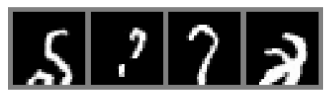

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 6/100, Train Loss: 1.0895, Val Loss: 1.0830


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 9/100, Train Loss: 1.0686, Val Loss: 1.0659


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/100, Train Loss: 1.0509, Val Loss: 1.0484


  0%|          | 0/28 [00:00<?, ?it/s]

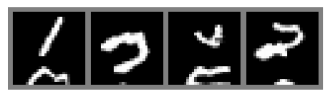

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 11/100, Train Loss: 1.0438, Val Loss: 1.0584


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 14/100, Train Loss: 1.0293, Val Loss: 1.0570


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/100, Train Loss: 1.0342, Val Loss: 1.0154


  0%|          | 0/28 [00:00<?, ?it/s]

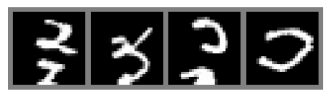

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 16/100, Train Loss: 1.0425, Val Loss: 1.0471


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 19/100, Train Loss: 1.0073, Val Loss: 1.0191


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/100, Train Loss: 0.9900, Val Loss: 0.9755


  0%|          | 0/28 [00:00<?, ?it/s]

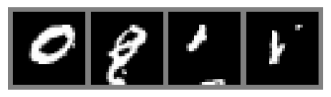

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 21/100, Train Loss: 0.9783, Val Loss: 0.9642


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 24/100, Train Loss: 0.9533, Val Loss: 0.9595


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 25/100, Train Loss: 0.9774, Val Loss: 0.9658


  0%|          | 0/28 [00:00<?, ?it/s]

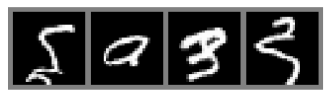

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 26/100, Train Loss: 0.9541, Val Loss: 0.9372


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 29/100, Train Loss: 0.9424, Val Loss: 0.9278


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 30/100, Train Loss: 0.9281, Val Loss: 0.9900


  0%|          | 0/28 [00:00<?, ?it/s]

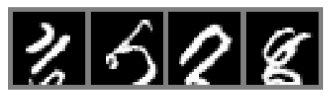

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 31/100, Train Loss: 0.9259, Val Loss: 1.1533


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 34/100, Train Loss: 0.9340, Val Loss: 0.9272


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 35/100, Train Loss: 0.9603, Val Loss: 1.0611


  0%|          | 0/28 [00:00<?, ?it/s]

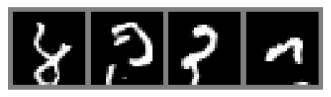

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 36/100, Train Loss: 0.9405, Val Loss: 0.9182


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 39/100, Train Loss: 0.9620, Val Loss: 0.9554


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 40/100, Train Loss: 0.9316, Val Loss: 0.9336


  0%|          | 0/28 [00:00<?, ?it/s]

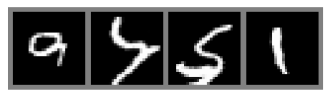

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 41/100, Train Loss: 0.9241, Val Loss: 0.9904


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 44/100, Train Loss: 0.9121, Val Loss: 0.9089


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 45/100, Train Loss: 0.9185, Val Loss: 0.9113


  0%|          | 0/28 [00:00<?, ?it/s]

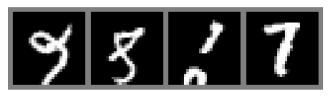

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 46/100, Train Loss: 0.9411, Val Loss: 0.9950


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 49/100, Train Loss: 0.9055, Val Loss: 0.9038


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 50/100, Train Loss: 0.8985, Val Loss: 0.9014


  0%|          | 0/28 [00:00<?, ?it/s]

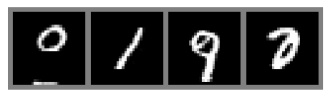

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 51/100, Train Loss: 0.8919, Val Loss: 0.8982


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 54/100, Train Loss: 0.8983, Val Loss: 0.9152


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 55/100, Train Loss: 0.8884, Val Loss: 0.8941


  0%|          | 0/28 [00:00<?, ?it/s]

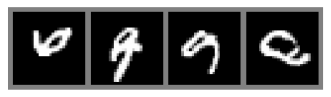

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 56/100, Train Loss: 0.9087, Val Loss: 0.9052


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 59/100, Train Loss: 0.8998, Val Loss: 1.0279


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 60/100, Train Loss: 0.9143, Val Loss: 0.8908


  0%|          | 0/28 [00:00<?, ?it/s]

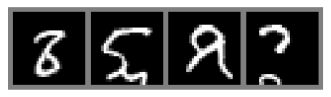

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 61/100, Train Loss: 0.9119, Val Loss: 0.9480


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 64/100, Train Loss: 0.8799, Val Loss: 0.8893


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 65/100, Train Loss: 0.9059, Val Loss: 0.8918


  0%|          | 0/28 [00:00<?, ?it/s]

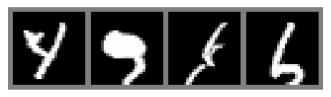

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 66/100, Train Loss: 0.9525, Val Loss: 0.9570


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 69/100, Train Loss: 0.9028, Val Loss: 0.9057


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 70/100, Train Loss: 0.8898, Val Loss: 0.9005


  0%|          | 0/28 [00:00<?, ?it/s]

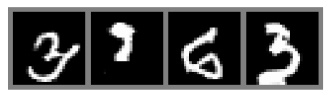

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 71/100, Train Loss: 0.8810, Val Loss: 0.9589


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 74/100, Train Loss: 0.8745, Val Loss: 0.8950


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 75/100, Train Loss: 0.8838, Val Loss: 0.8855


  0%|          | 0/28 [00:00<?, ?it/s]

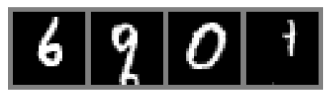

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 76/100, Train Loss: 0.8694, Val Loss: 0.8830


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 79/100, Train Loss: 0.9162, Val Loss: 0.8929


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 80/100, Train Loss: 0.9342, Val Loss: 0.9401


  0%|          | 0/28 [00:00<?, ?it/s]

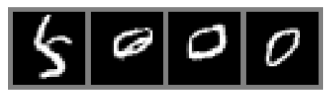

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 81/100, Train Loss: 0.8670, Val Loss: 0.8823


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 84/100, Train Loss: 0.8830, Val Loss: 0.8896


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 85/100, Train Loss: 0.8754, Val Loss: 0.8888


  0%|          | 0/28 [00:00<?, ?it/s]

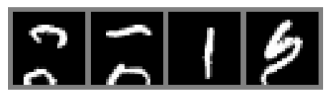

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 86/100, Train Loss: 0.8651, Val Loss: 0.8825


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 89/100, Train Loss: 0.8627, Val Loss: 0.8787


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 90/100, Train Loss: 0.8594, Val Loss: 0.8778


  0%|          | 0/28 [00:00<?, ?it/s]

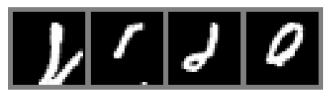

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 91/100, Train Loss: 0.9167, Val Loss: 0.9249


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 94/100, Train Loss: 0.8742, Val Loss: 0.8858


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 95/100, Train Loss: 0.8703, Val Loss: 0.8841


  0%|          | 0/28 [00:00<?, ?it/s]

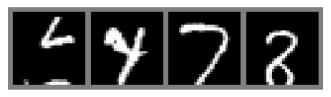

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 96/100, Train Loss: 0.8703, Val Loss: 0.8848


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 99/100, Train Loss: 0.8711, Val Loss: 0.8924


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100/100, Train Loss: 0.8592, Val Loss: 0.8790


  0%|          | 0/28 [00:00<?, ?it/s]

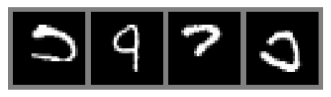

  0%|          | 0/79 [00:00<?, ?it/s]

Test Loss: 0.8668


In [35]:
# Training loop
train_bpd = []
val_bpd = []

for epoch in range(epochs):
    model.train()
    losses = []

    for imgs, _ in tqdm(train_loader, leave=False):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model.calc_nll(imgs)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    train_bpd.append(np.mean(losses))
    scheduler.step()

    losses = []
    with torch.no_grad():
      for imgs, _ in tqdm(val_loader, leave=False):
          imgs = imgs.to(device)
          loss = model.calc_nll(imgs)
          losses.append(loss.item())

    val_bpd.append(np.mean(losses))

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_bpd[-1]:.4f}, Val Loss: {val_bpd[-1]:.4f}")

    if (epoch + 1) % 5 == 0:
       sampled_images = model.sample(img_shape=(4, 1, 28, 28))
       show_imgs(sampled_images)

# Test loop
model.eval()
losses = []
for imgs, _ in tqdm(test_loader, leave=False):
    imgs = imgs.to(device)
    loss = model.calc_nll(imgs)
    losses.append(loss.item())

test_bpd = np.mean(losses)
print(f"Test Loss: {test_bpd:.4f}")

## Question 1

## Question 2

## Question 3